In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools

In [42]:
data = pd.read_csv('Nat_Gas.csv')

In [43]:
data["Dates"] = pd.to_datetime(data["Dates"])
data.sort_values(["Dates"])
data["Prices"] = pd.to_numeric(data["Prices"], errors='coerce')
data = data.dropna()  # или заполните по правилу из вашего материала (шаг 1: "замена на NA или усреднение по соседним")
print(data.head(10))
print(data.isnull().sum())
print(data.shape)

       Dates  Prices
0 2020-10-31   10.10
1 2020-11-30   10.30
2 2020-12-31   11.00
3 2021-01-31   10.90
4 2021-02-28   10.90
5 2021-03-31   10.90
6 2021-04-30   10.40
7 2021-05-31    9.84
8 2021-06-30   10.00
9 2021-07-31   10.10
Dates     0
Prices    0
dtype: int64
(48, 2)


C:\Users\User\AppData\Local\Temp\ipykernel_26160\1646588631.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Dates"] = pd.to_datetime(data["Dates"])


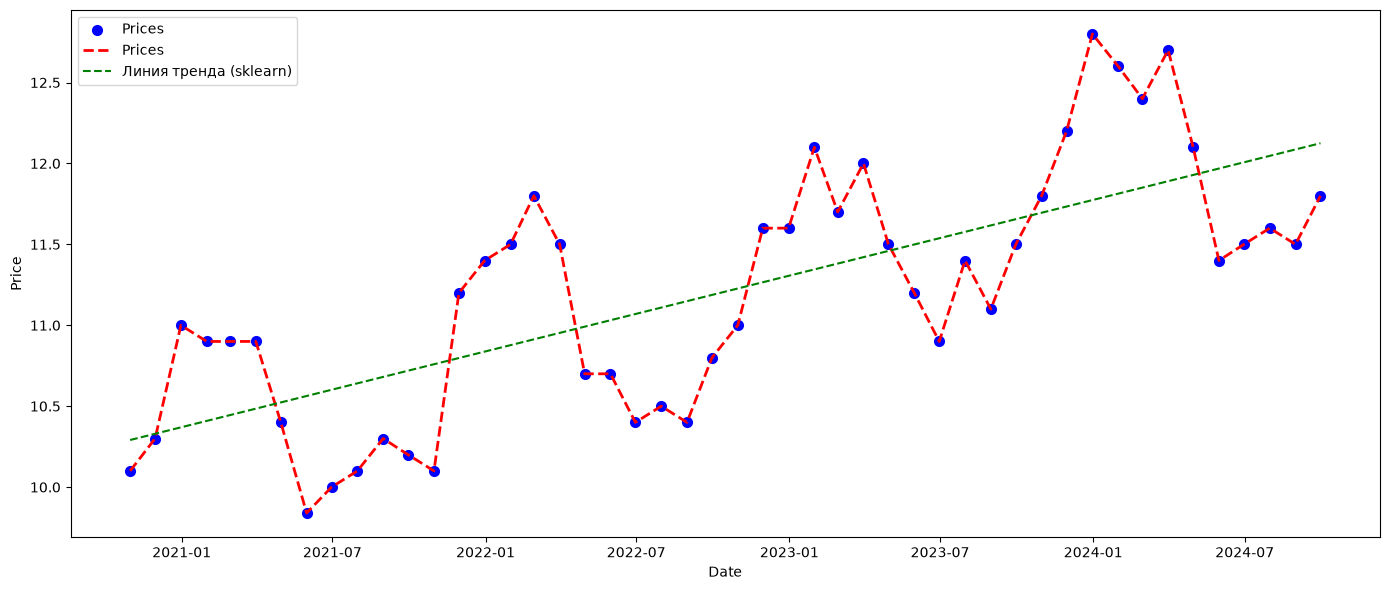

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(
    data["Dates"],
    data["Prices"],
    linewidth=2,
    marker="o",
    color="blue",
    label="Prices"
)

ax.plot(
    data["Dates"],
    data["Prices"],
    linewidth=2,
    linestyle="--",
    color="red",
    label="Prices"
)

x = (
    data["Dates"] - data["Dates"].min()
).dt.days.to_numpy().reshape(-1, 1)
y = data["Prices"].to_numpy()
model = LinearRegression()
model.fit(x, y)  # X должен быть 2D array
trend_values = model.predict(x)
plt.plot(data["Dates"], trend_values, 'g--', label='Линия тренда (sklearn)')

ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()

plt.tight_layout()
plt.show()

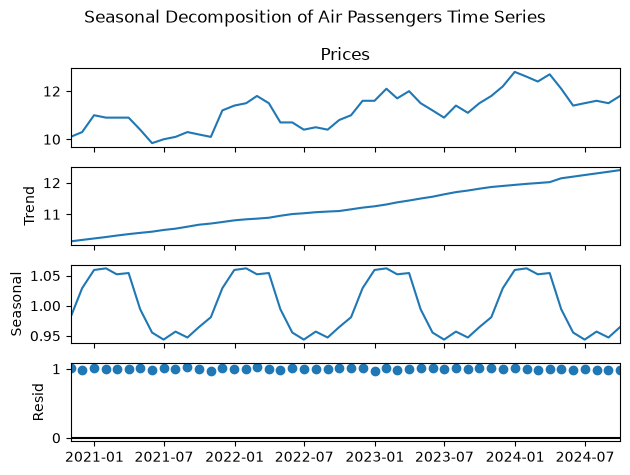

In [32]:
# Decompose the time series into trend, seasonal and residual components
data["Dates"] = pd.to_datetime(data["Dates"])
data["Prices"] = pd.to_numeric(data["Prices"], errors="coerce")

price_series = (
    data
    .dropna(subset=["Dates", "Prices"])
    .sort_values("Dates")
    .set_index("Dates")["Prices"]
)

result = seasonal_decompose(
    price_series, model='multiplicative', extrapolate_trend='freq')
result.plot()
plt.suptitle('Seasonal Decomposition of Air Passengers Time Series')
plt.tight_layout()
plt.show()

In [33]:
data["Dates"] = pd.to_datetime(data["Dates"])
df = data.set_index("Dates").copy()

In [34]:
df = df.dropna()
result = adfuller(df)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
    print("Series is non stationary; differencing is needed.")
else:
    print("Series is stationary; no differencing needed.")

ADF Statistic: 0.218077
p-value: 0.973257
Series is non stationary; differencing is needed.


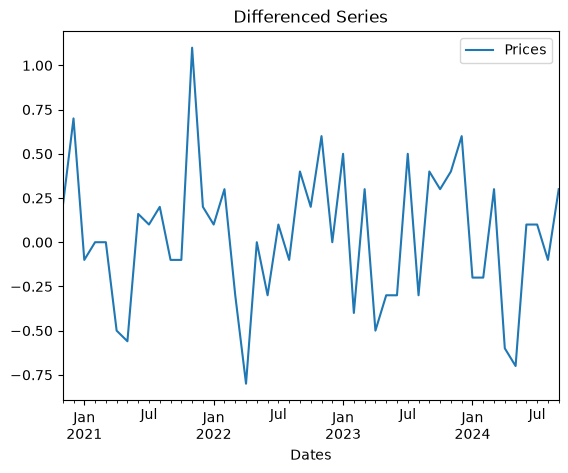

ADF Statistic (differenced): -6.844774
p-value (differenced): 0.000000


In [35]:
ts_diff = df.diff().dropna()

ts_diff.plot(title='Differenced Series')
plt.show()

result_diff = adfuller(ts_diff)
print('ADF Statistic (differenced): %f' % result_diff[0])
print('p-value (differenced): %f' % result_diff[1])

In [45]:
data = data.set_index('Dates')['Prices']  # теперь Series с DatetimeIndex
print(type(data))
print(data.dtype)
print(data.index)

<class 'pandas.Series'>
float64
DatetimeIndex(['2020-10-31', '2020-11-30', '2020-12-31', '2021-01-31',
               '2021-02-28', '2021-03-31', '2021-04-30', '2021-05-31',
               '2021-06-30', '2021-07-31', '2021-08-31', '2021-09-30',
               '2021-10-31', '2021-11-30', '2021-12-31', '2022-01-31',
               '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31',
               '2022-06-30', '2022-07-31', '2022-08-31', '2022-09-30',
               '2022-10-31', '2022-11-30', '2022-12-31', '2023-01-31',
               '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31',
               '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30',
               '2023-10-31', '2023-11-30', '2023-12-31', '2024-01-31',
               '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31',
               '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30'],
              dtype='datetime64[us]', name='Dates', freq=None)


In [46]:
T = len(ts_diff.dropna())
max_lags = int(min(10 * np.log10(T), T // 4))

In [47]:
# ---------- Шаг 4: пилотные p и q по ACF/PACF на дифференцированном ряде ----------
from statsmodels.tsa.stattools import acf, pacf

conf = 1.96 / np.sqrt(T)

acf_vals = acf(ts_diff.dropna(), nlags=max_lags)
pacf_vals = pacf(ts_diff.dropna(), nlags=max_lags)

# лаги, значимо отличные от нуля -> кандидаты в q и p соответственно
q_candidates = [i for i in range(1, len(acf_vals)) if abs(acf_vals[i]) > conf]
p_candidates = [i for i in range(1, len(pacf_vals)) if abs(pacf_vals[i]) > conf]

p_range = range(0, max(p_candidates, default=1) + 1)
q_range = range(0, max(q_candidates, default=1) + 1)

def aicc(results, p, q):
    """AICc из материала — поправка для коротких рядов."""
    T = results.nobs
    k = p + q + 1
    ll = results.llf
    aic = -2 * ll + 2 * k
    if T - k - 2 <= 0:
        return np.inf  # поправка не определена при слишком коротком ряде
    return aic + (2 * k * (k + 1)) / (T - k - 2)

best_crit = np.inf
best_order = None
best_model = None
d=1
for p, q in itertools.product(p_range, q_range):
    order = (p, d, q)
    try:
        results = ARIMA(data, order=order).fit()
        crit = aicc(results, p, q)  # можно заменить на results.aic или results.bic
        if crit < best_crit:
            best_crit = crit
            best_order = order
            best_model = results
    except Exception as e:
        print(order, "FAILED:", repr(e))

print(f"Лучший порядок ARIMA: {best_order}, AICc = {best_crit:.2f}")

c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequen

Лучший порядок ARIMA: (3, 1, 7), AICc = 25.98


c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\User\Desktop\jp_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: Conv

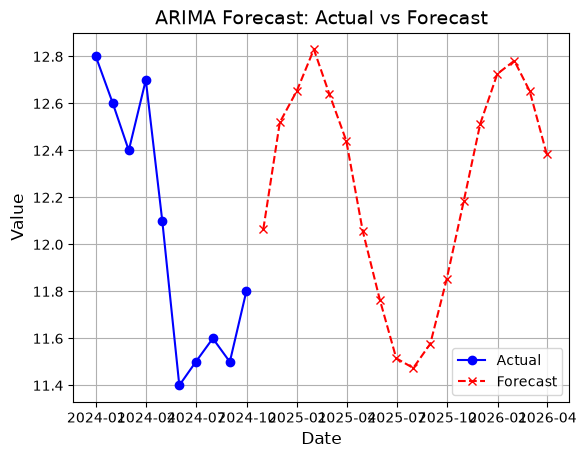

In [48]:
final_model = ARIMA(data, order=best_order)
results = final_model.fit()

forecast_values = results.forecast(steps=18)

plt.plot(data[-10:].index, data[-10:], label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', linestyle='--', marker='x')

plt.title('ARIMA Forecast: Actual vs Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()